In [29]:
import numpy as np
from scipy import sparse
from scipy.sparse import linalg
from numpy.linalg import norm

def baseline_arPLS(y, ratio=1e-8, lam=800, niter=5000, full_output=True):
    L = len(y)
    diag = np.ones(L - 2)
    D = sparse.spdiags([diag, -2*diag, diag], [0, -1, -2], L, L - 2)
    H = lam * D.dot(D.T)  # The transposes are flipped w.r.t the Algorithm on pg. 252
    w = np.ones(L)
    W = sparse.spdiags(w, 0, L, L)
    crit = 1
    count = 0

    while crit > ratio:
        z = linalg.spsolve(W + H, W * y)
        d = y - z
        dn = d[d < 0]
        m = np.mean(dn)
        s = np.std(dn)
        w_new = 1 / (1 + np.exp(2 * (d - (2*s - m))/s))
        crit = norm(w_new - w) / norm(w)
        w = w_new
        W.setdiag(w)  # Do not create a new matrix, just update diagonal values
        count += 1

        if count > niter:
            print('Maximum number of iterations exceeded')
            break

    if full_output:
        info = {'num_iter': count, 'stop_criterion': crit}
        return z, d, info
    else:
        return z

# Votre dataset
mean_timeserie_flat_masked_select = np.array([
    2366.68852295, 2349.26002994, 2338.63932136, 2324.72849301, 2309.63268463,
    2298.43677645, 2290.86112774, 2284.12120758, 2275.76901198, 2266.21656687,
    2255.71442116, 2243.81032934, 2234.83343313, 2226.52689621, 2215.90693613,
    2209.19800399, 2202.24326347, 2194.39580838, 2187.5244012, 2179.39126747,
    2173.32125749, 2165.91526946, 2153.91576846, 2146.63148703, 2139.25558882,
    2132.41516966, 2123.7496507, 2115.39431138, 2109.83867265, 2100.8506986,
    2095.66167665, 2090.73163673, 2085.22240519, 2076.26432136, 2070.9242016,
    2065.83308383, 2057.82180639, 2051.43243513, 2045.61621756, 2042.97175649,
    2037.7991018, 2034.13433134, 2028.27924152, 2022.27130739, 2016.31192615,
    2011.37649701, 2006.33997006, 2000.09331337, 1994.33073852, 1992.22110778,
    1996.41591816, 2032.15923154, 2048.1746507, 2057.15978044, 2064.96062874,
    2066.83997006, 2071.66891218, 2071.15319361, 2071.66067864, 2064.33208583,
    2061.65648703, 2056.66462076, 2036.56511976, 2012.81472056, 1994.80384232,
    1978.68977046, 1968.07200599, 1957.25873253, 1945.9007984, 1935.97345309,
    1930.80194611, 1924.29780439, 1918.4992515, 1910.04406188, 1904.58717565,
    1903.12994012, 1896.9004491, 1891.4762475, 1885.22165669, 1879.9742016,
    1882.42100798, 1875.31487026, 1867.08293413, 1862.5755988, 1857.22639721,
    1852.21881238, 1850.06067864, 1845.11676647, 1839.17999002, 1836.3992016,
    1834.75668663, 1830.21611776, 1825.55628743, 1822.69316367, 1819.87065868,
    1814.25359281, 1812.90528942, 1807.6, 1804.28068862, 1802.99585828,
    1798.16112774, 1793.61826347, 1790.599501, 1789.3008483, 1786.99840319,
    1782.18767465, 1780.03168663, 1781.79785429, 1777.20818363, 1773.44116766,
    1768.1240519, 1766.10748503, 1765.31217565, 1764.05773453, 1760.05963074,
    1758.01142715, 1756.57754491, 1751.88767465, 1751.06167665, 1748.18008982,
    1745.52360279, 1744.15139721, 1739.80279441, 1738.25154691, 1736.26412176,
    1733.61172655, 1732.21591816, 1730.49451098, 1729.2246008, 1727.93048902,
    1726.7241517, 1724.56946108, 1724.44301397, 1723.86571856, 1717.98867265,
    1717.04381238, 1716.3004491, 1715.88832335, 1713.47894212, 1712.04256487,
    1709.97759481, 1707.14101796, 1705.97200599, 1705.76402196, 1705.14181637,
    1701.39306387, 1699.02709581, 1706.175998, 1702.36926148, 1699.79256487
])

# Exécution avec vos paramètres
spectra_arPLS_select, d, info = baseline_arPLS(
    mean_timeserie_flat_masked_select,
    ratio=1e-5,
    lam=10,
    niter=5000,
    full_output=True
)

spectra_arPLS_select_1, d, info = baseline_arPLS(
    mean_timeserie_flat_masked_select,
    ratio=1e-5,
    lam=0.1,
    niter=5000,
    full_output=True
)

spectra_arPLS_select_100, d, info = baseline_arPLS(
    mean_timeserie_flat_masked_select,
    ratio=1e-5,
    lam=1000,
    niter=5000,
    full_output=True
)


/var/folders/57/fz9f573j4j3539hd3vxk7w6c0000gp/T/ipykernel_13539/3588104119.py:22: RuntimeWarning: overflow encountered in exp
  w_new = 1 / (1 + np.exp(2 * (d - (2*s - m))/s))


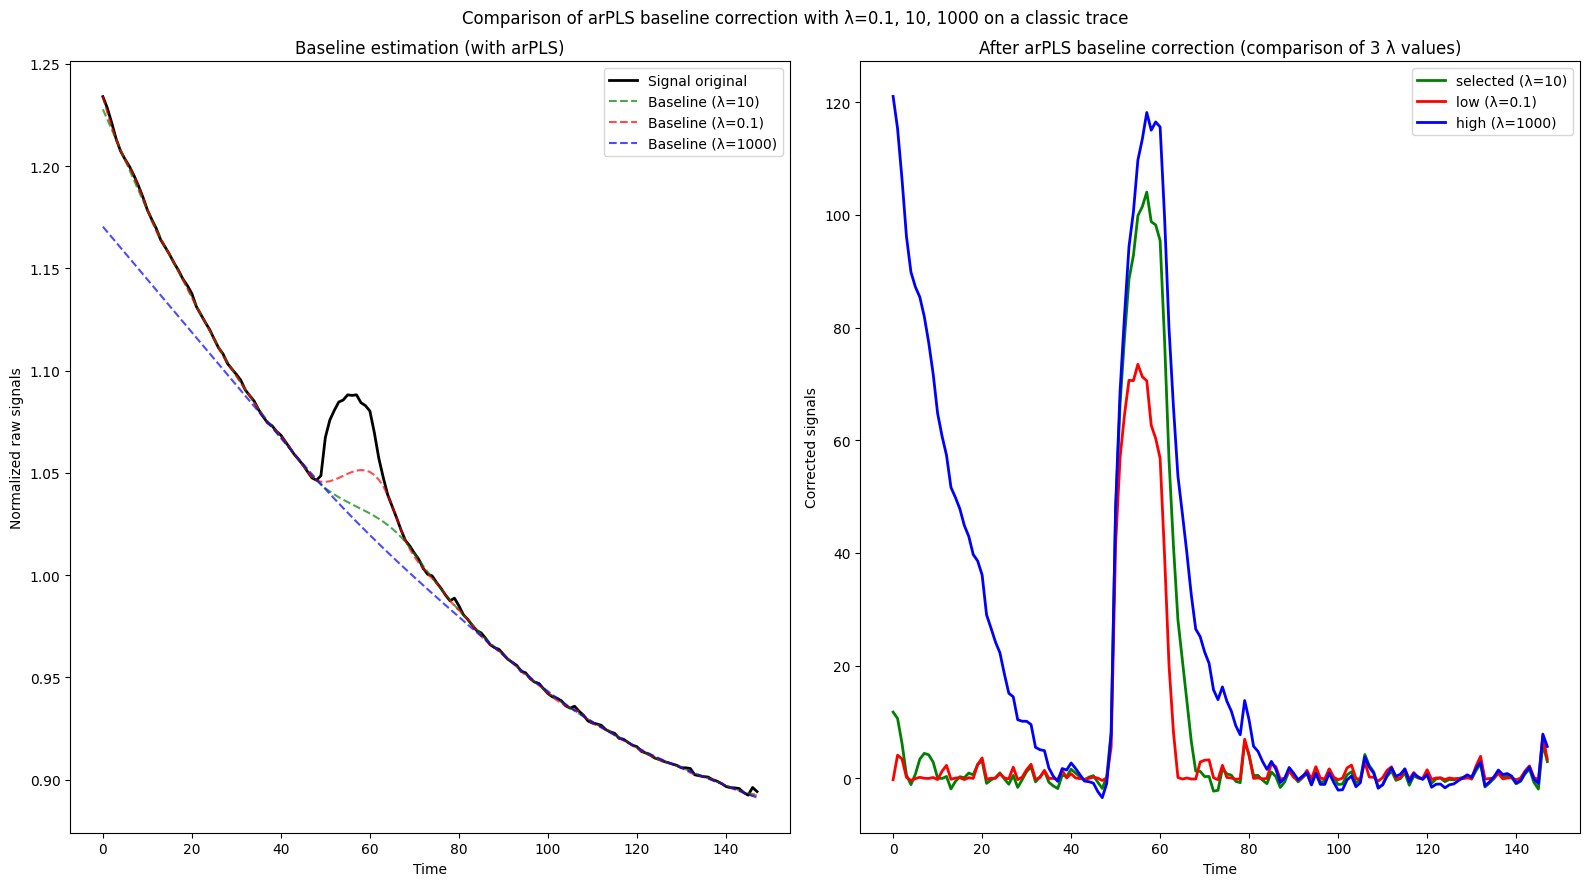

In [32]:
import matplotlib.pyplot as plt
import numpy as np

# Exécution des 4 configurations (vous avez déjà calculé spectra_arPLS_select, spectra_arPLS_select_1, spectra_arPLS_select_100)
fig, axs = plt.subplots(1, 2, figsize=(16, 9))

# --- Sous-graphe 1 : Signal original (before correction) ---
facto_s = np.percentile(mean_timeserie_flat_masked_select[1:149], 50)
axs[0].plot(mean_timeserie_flat_masked_select[1:149] / facto_s,
           label='Signal original',
           color='black', linewidth=2)

# Ajout des lignes de base (pour référence)
axs[0].plot(spectra_arPLS_select[1:149] / facto_s,
           label='Baseline (λ=10)', color='green', linestyle='--', alpha=0.7)
axs[0].plot(spectra_arPLS_select_1[1:149] / facto_s,
           label='Baseline (λ=0.1)', color='red', linestyle='--', alpha=0.7)
axs[0].plot(spectra_arPLS_select_100[1:149] / facto_s,
           label='Baseline (λ=1000)', color='blue', linestyle='--', alpha=0.7)

axs[0].set_title('Baseline estimation (with arPLS)')
axs[0].set_ylabel('Normalized raw signals')
axs[0].set_xlabel('Time')
axs[0].legend(loc='upper right')

# --- Sous-graphe 2 : Signaux corrigés (after correction) ---
facto_b = np.percentile(mean_timeserie_flat_masked_select[1:149], 50)

# Signal corrigé avec λ=10 (vert)
axs[1].plot(mean_timeserie_flat_masked_select[1:149] - spectra_arPLS_select[1:149],
           label='selected (λ=10)', color='green', linewidth=2)

# Signal corrigé avec λ=1 (rouge)
axs[1].plot(mean_timeserie_flat_masked_select[1:149] - spectra_arPLS_select_1[1:149],
           label='low (λ=0.1)', color='red', linewidth=2)

# Signal corrigé avec λ=100 (bleu)
axs[1].plot(mean_timeserie_flat_masked_select[1:149] - spectra_arPLS_select_100[1:149],
           label='high (λ=1000)', color='blue', linewidth=2)

axs[1].set_title('After arPLS baseline correction (comparison of 3 λ values)')
axs[1].set_ylabel('Corrected signals')
axs[1].set_xlabel('Time')
axs[1].legend(loc='upper right')

# Titre global
fig.suptitle('Comparison of arPLS baseline correction with λ=0.1, 10, 1000 on a classic trace')
plt.tight_layout()
plt.show()